## 1. Configuração do ambiente =========================

In [ ]:
# Bibliotecas básicas
import os
import math
import pandas as pd
import numpy as np
import warnings
import kagglehub

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Estatística
from scipy import stats

# Configurações para ignorar warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Configurar o KaggleHub para acessar o dataset
path = kagglehub.dataset_download("yeanzc/telco-customer-churn-ibm-dataset")
print("Path to dataset files:", path)

for filename in os.listdir(path):
    print(filename)

Path to dataset files: C:\Users\gustavo.dellanhol\.cache\kagglehub\datasets\yeanzc\telco-customer-churn-ibm-dataset\versions\1
Telco_customer_churn.xlsx


## 2. Carregamento dos dados =========================

### **Dataset**: [Telco customer churn: IBM dataset](https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset/data)

O dataset consiste em um conjunto de dados fictício de uma empresa de telecomunicações com 7.043 clientes na California

- Ao todo temos 33 colunas, sendo elas:
    - **CustomerID:** Um ID único que identifica cada cliente.
    - **Count:** Um valor usado em relatórios/dashboards para somar o número de clientes em um conjunto filtrado.
    - **Country:** País de residência principal do cliente.
    - **State:** Estado de residência principal do cliente.
    - **City:** Cidade de residência principal do cliente.
    - **Zip Code:** CEP da residência principal do cliente.
    - **Lat Long:** Combinação de latitude e longitude da residência principal do cliente.
    - **Latitude:** Latitude da residência principal do cliente.
    - **Longitude:** Longitude da residência principal do cliente.
    - **Gender:** Gênero do cliente: Masculino, Feminino.
    - **Senior Citizen:** Indica se o cliente tem 65 anos ou mais: Sim, Não.
    - **Partner:** Indica se o cliente tem parceiro(a): Sim, Não.
    - **Dependents:** Indica se o cliente vive com dependentes: Sim, Não. Dependentes podem ser filhos, pais, avós etc.
    - **Tenure Months:** Total de meses em que o cliente permaneceu na empresa até o fim do trimestre de referência.
    - **Phone Service:** Indica se o cliente assina serviço de telefone residencial com a empresa: Sim, Não.
    - **Multiple Lines:** Indica se o cliente assina múltiplas linhas telefônicas: Sim, Não.
    - **Internet Service:** Indica se o cliente assina serviço de internet: Não, DSL, Fibra Óptica, Cabo.
    - **Online Security:** Indica se o cliente assina serviço adicional de segurança online: Sim, Não.
    - **Online Backup:** Indica se o cliente assina serviço adicional de backup online: Sim, Não.
    - **Device Protection:** Indica se o cliente assina plano adicional de proteção de dispositivo para equipamentos de internet: Sim, Não.
    - **Tech Support:** Indica se o cliente assina plano adicional de suporte técnico com menor tempo de espera: Sim, Não.
    - **Streaming TV:** Indica se o cliente usa internet para assistir TV por streaming de terceiros: Sim, Não. A empresa não cobra taxa adicional por esse serviço.
    - **Streaming Movies:** Indica se o cliente usa internet para assistir filmes por streaming de terceiros: Sim, Não. A empresa não cobra taxa adicional por esse serviço.
    - **Contract:** Tipo de contrato atual do cliente: Mensal, Um Ano, Dois Anos.
    - **Paperless Billing:** Indica se o cliente optou por fatura digital: Sim, Não.
    - **Payment Method:** Forma de pagamento da fatura: Débito em Conta, Cartão de Crédito, Cheque por Correio.
    - **Monthly Charge:** Valor total mensal atual cobrado pelos serviços contratados.
    - **Total Charges:** Valor total acumulado cobrado do cliente até o fim do trimestre de referência.
    - **Churn Label:** Sim = cliente saiu da empresa neste trimestre. Não = cliente permaneceu. Diretamente relacionado a Churn Value.
    - **Churn Value:** 1 = cliente saiu da empresa neste trimestre. 0 = cliente permaneceu. Diretamente relacionado a Churn Label.
    - **Churn Score:** Valor de 0 a 100 calculado pelo IBM SPSS Modeler. O modelo considera múltiplos fatores associados ao churn. Quanto maior o score, maior a probabilidade de churn.
    - **CLTV:** Customer Lifetime Value. Um CLTV previsto é calculado com fórmulas corporativas e dados existentes. Quanto maior o valor, mais valioso é o cliente. Clientes de alto valor devem ser monitorados para churn.
    - **Churn Reason:** Motivo específico de saída do cliente. Diretamente relacionado à categoria de churn.

In [ ]:
df = pd.read_excel(path + "/Telco_customer_churn.xlsx")

print("Shape do dataset: ", df.shape)
df.head()

Shape do dataset:  (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [ ]:
# Informações gerais sobre o dataset
print("=== INFORMAÇÕES GERAIS DO DATASET ===\n")
display(df.info())

print("\n=== ESTATÍSTICAS DESCRITIVAS ===\n")
display(df.describe())
display(df.describe(include='object')) # type: ignore

# Dropando a coluna Churn Score, que já contem previsão de churn e pode enviesar o modelo
if 'Churn Score' in df.columns: df.drop(columns=['Churn Score'], inplace=True)

# Dropando a coluna Count, que é irrelevante para a análise
if 'Count' in df.columns: df.drop(columns=['Count'], inplace=True)

# Tipando devidamente variáveis não numéricas
df[['Latitude', 'Longitude', 'Zip Code']] = df[['Latitude', 'Longitude', 'Zip Code']].astype(str)

# Tipando devidamente a variável `Total Charges`
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# Renomear variável `Churn Value` para `target`
df.rename(columns={'Churn Value': 'target'}, inplace=True)

print ("\n === COLUNAS NUMÉRICAS ===" )
# lista das colunas numéricas. Essa variável será utilizada para facilitar a criação de gráficos
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.to_list()
num_cols.remove('target')  # Remover a variável target da lista de colunas numéricas
print(num_cols)

# Converter colunas geográficas para tipo numérico após armazenar o num_cols
df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')

=== INFORMAÇÕES GERAIS DO DATASET ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null 

None


=== ESTATÍSTICAS DESCRITIVAS ===



,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


,CustomerID,Country,State,City,Lat Long,Gender,Senior Citizen,Partner,Dependents,Phone Service,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Total Charges,Churn Label,Churn Reason
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043,7043,1869
unique,7043,1,1,1129,1652,2,2,2,2,2,...,3,3,3,3,3,2,4,6531,2,20
top,3668-QPYBK,United States,California,Los Angeles,"34.159534, -116.425984",Male,No,No,No,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,,No,Attitude of support person
freq,1,7043,7043,305,5,3555,5901,3641,5416,6361,...,3095,3473,2810,2785,3875,4171,2365,11,5174,192



 === COLUNAS NUMÉRICAS ===
['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']


## 3. Análise Exploratória =========================

### 3.1 Missing Values

**Objetivo:** Identificar valores ausentes e analisar como eles estão distribuídos nos dados

=== ANÁLISE DE MISSING VALUES ===

                      Coluna  Missing_Count  Missing_Percentage
Churn Reason    Churn Reason           5174               73.46
Total Charges  Total Charges             11                0.16


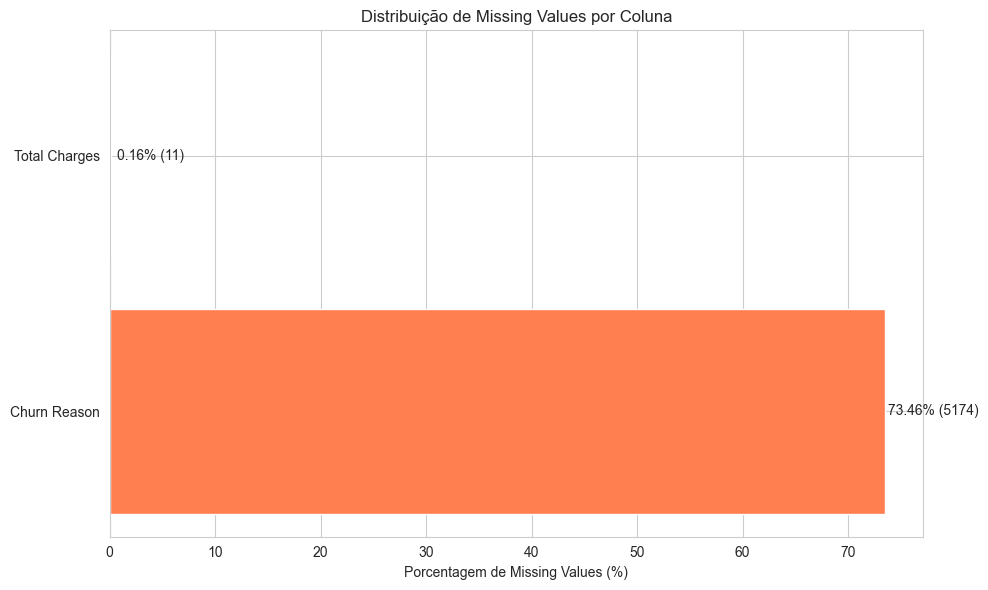

In [4]:
# Análise de valores ausentes
print("=== ANÁLISE DE MISSING VALUES ===\n")

missing_values = pd.DataFrame({
    'Coluna': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values = missing_values[missing_values['Missing_Count'] > 0].sort_values(
    by='Missing_Percentage', ascending=False
)

if len(missing_values) > 0:
    print(missing_values)
    
    # Visualizar missing values
    plt.figure(figsize=(10, 6))
    plt.barh(missing_values['Coluna'], missing_values['Missing_Percentage'], color='coral')
    plt.xlabel('Porcentagem de Missing Values (%)')
    plt.title('Distribuição de Missing Values por Coluna')

    #Adiciona os valores nas barras
    for i, (pct, cnt) in enumerate(zip(missing_values['Missing_Percentage'], missing_values['Missing_Count'])):
        offset = 0.5 if pct < 1 else 0.3
        plt.text(pct + offset, i, f"{pct}% ({cnt})", va='center')
    
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum missing value detectado!")

### 3.1.1 Tratamento de Missing Values 

**Objetivo:** Realizar o tratamento de valores ausentes nos dados

In [ ]:
print("=== TRATAMENTO DE MISSING VALUES NA COLUNA 'Churn Reason' ===")
print(df["Churn Reason"].isnull().sum(), "missing values")
df['Churn Reason'].fillna('Not churned', inplace=True)
print("Preenchido com 'Not Churned'")

print("\n=== TRATAMENTO DE MISSING VALUES NA COLUNA 'Total Charges' ===")
print(df["Total Charges"].isnull().sum(), "missing values")

# Preencher com 0 apenas quando Tenure Months == 0 (clientes novos sem cobrança registrada)
df.loc[(df['Tenure Months'] == 0) & (df['Total Charges'].isnull()), 'Total Charges'] = 0
print("Preenchido com 0 para clientes com Tenure Months == 0")

=== TRATAMENTO DE MISSING VALUES NA COLUNA 'Churn Reason' ===
5174 missing values
Preenchido com 'Not Churned'

=== TRATAMENTO DE MISSING VALUES NA COLUNA 'Total Charges' ===
11 missing values
Preenchido com 0 para clientes com Tenure Months == 0


### 3.2 Variável Target

**Objetivo:** Entender como a variável que o modelo vai prever se comporta

=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===

Contagem:


target
0    5174
1    1869
Name: count, dtype: int64


Percentual:
Não deixou a empresa (0): 73.46%
Deixou a empresa (1): 26.54%


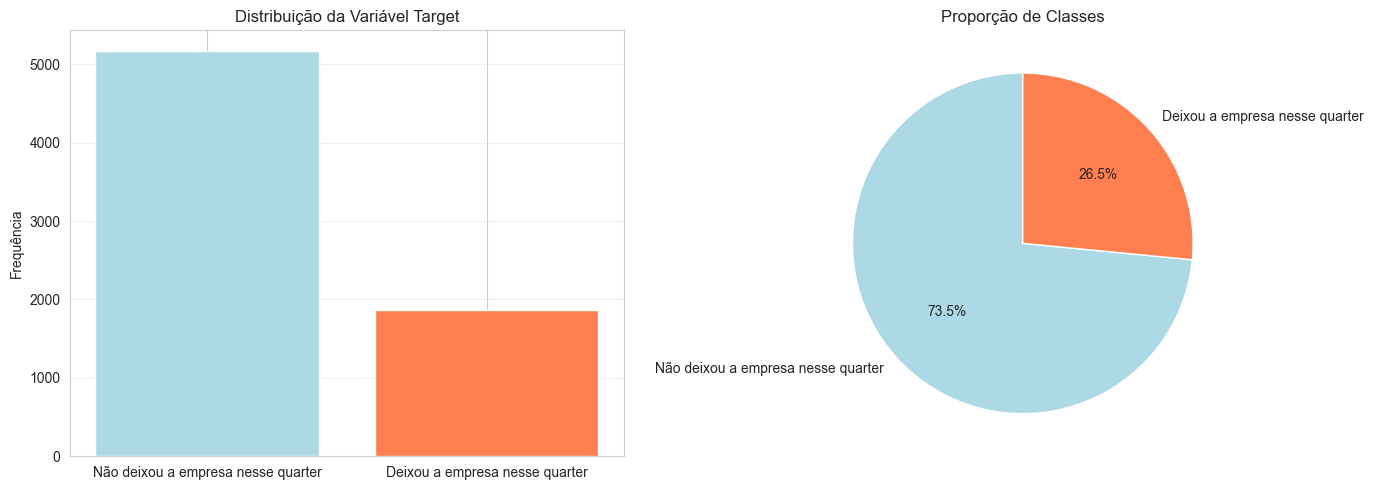


Ratio de balanceamento: 0.36
⚠️ Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.


In [6]:
print("=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===\n")
target_counts = df['target'].value_counts()
target_percentages = df['target'].value_counts(normalize=True) * 100

print("Contagem:")
display(target_counts)
print("\nPercentual:")
for idx, pct in target_percentages.items():
    label = "Não deixou a empresa" if idx == 0 else "Deixou a empresa"
    print(f"{label} ({idx}): {pct:.2f}%")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
axes[0].bar(['Não deixou a empresa nesse quarter', 'Deixou a empresa nesse quarter'], 
            target_counts.values, color=['lightblue', 'coral'])
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição da Variável Target')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de pizza
axes[1].pie(target_counts.values, labels=['Não deixou a empresa nesse quarter', 'Deixou a empresa nesse quarter'], 
            autopct='%1.1f%%', colors=['lightblue', 'coral'], startangle=90)
axes[1].set_title('Proporção de Classes')

plt.tight_layout()
plt.show()

# Verificar se há desbalanceamento
ratio = target_counts.min() / target_counts.max()
print(f"\nRatio de balanceamento: {ratio:.2f}")
if ratio < 0.5:
    print("⚠️ Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.")
else:
    print("✓ Dataset razoavelmente balanceado.")

A variável target apresenta desbalanceamento moderado, com 73,5% de clientes que não churnaram e 26,5% que churnaram (ratio ≈ 0,36). Esse cenário pode impactar negativamente o desempenho do modelo na identificação da classe minoritária, sendo necessário o uso de métricas apropriadas (como recall e F1-score) e possíveis técnicas de balanceamento, como class_weight ou SMOTE.

### 3.3 Análise de Outliers

**Objetivo:** Identificar valores extremos nas variáveis numéricas que possam representar erros de medição ou comportamentos atípicos relevantes para a análise.

**Métodos utilizados:**

- **Z-score:** utilizado para detectar observações que se encontram a mais de 3 desvios padrão da média, sendo consideradas potenciais outliers.</p>

- **Visualização:** utilização de boxplots para identificar visualmente a presença de valores discrepantes e compreender a distribuição dos dados.

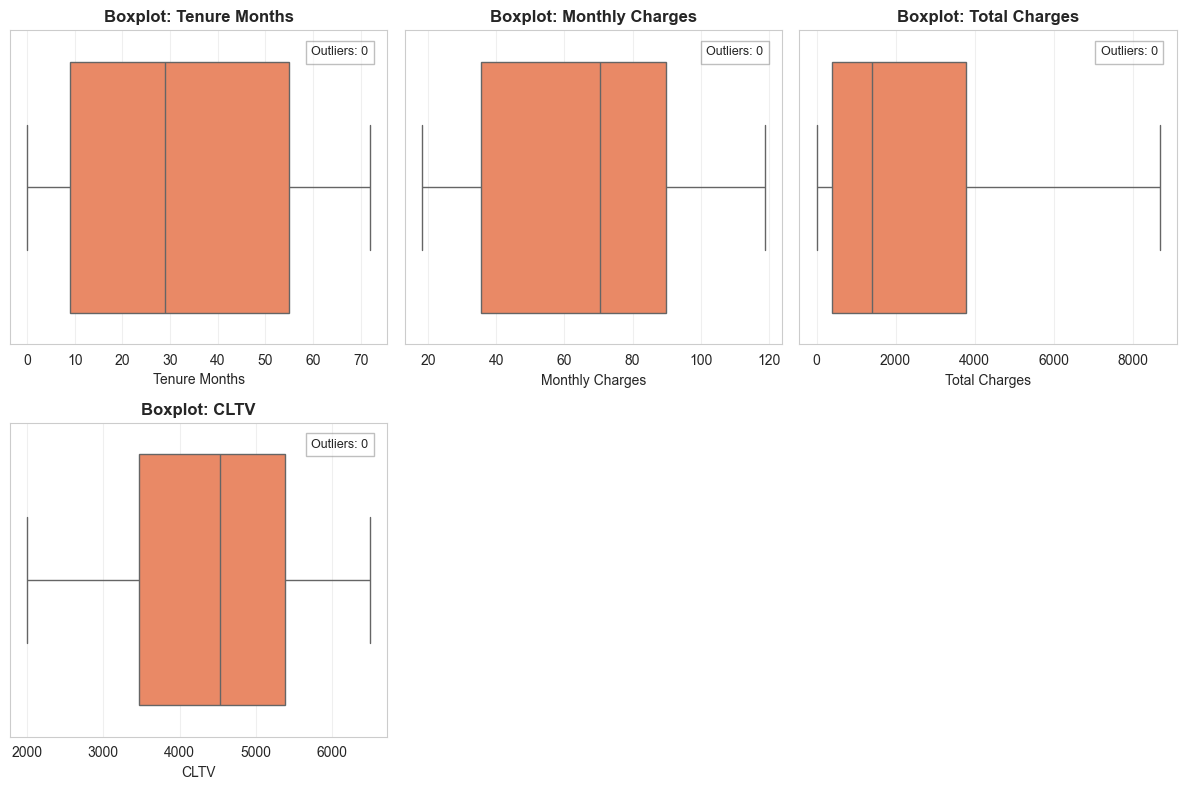

In [ ]:
n = len(num_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.ravel()

for idx, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[idx], color='coral')
    axes[idx].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].grid(axis='x', alpha=0.3)
    col_zscore = np.abs(stats.zscore(df[col].dropna())) # type: ignore
    outlier_count = (col_zscore > 3).sum()
    axes[idx].text(0.95, 0.95, f'Outliers: {outlier_count}', 
                   transform=axes[idx].transAxes, fontsize=9,
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


A ausência de outliers relevantes indica estabilidade nas distribuições das variáveis, reduzindo a necessidade de intervenções e contribuindo para maior confiabilidade nas análises e modelagem

### 3.4 Anomalias e valores inválidos

Como não houve outliers significativos, não é necessário aplicar técnicas de tratamento.

### 3.5 Análise de Distribuições

Distribuição das variáveis numéricas (identificar assimetrias)

=== ANÁLISE DE ASSIMETRIA (SKEWNESS) E CURTOSE ===

         Coluna  Skewness  Kurtosis         Interpretação
  Tenure Months     0.240    -1.387                Normal
Monthly Charges    -0.221    -1.257                Normal
  Total Charges     0.963    -0.229 Assimétrica à direita
           CLTV    -0.312    -0.934                Normal


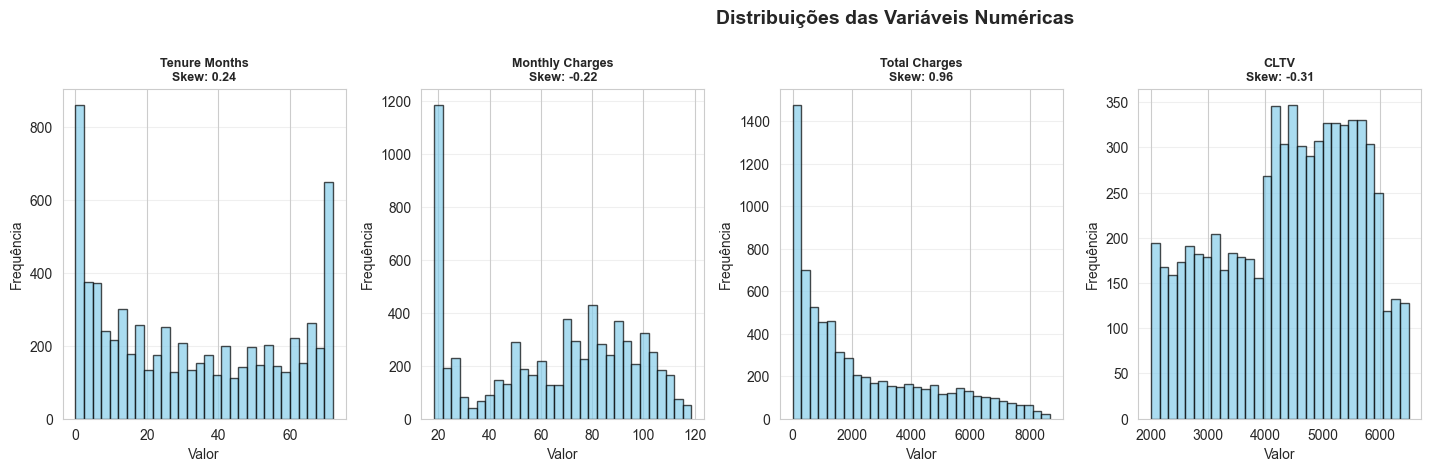

In [ ]:
# Análise de distribuições
print("=== ANÁLISE DE ASSIMETRIA (SKEWNESS) E CURTOSE ===\n")

distribution_stats = []
for col in num_cols:
    skewness = df[col].skew()
    kurtosis = df[col].kurtosis()
    distribution_stats.append({
        'Coluna': col,
        'Skewness': round(skewness, 3), # type: ignore
        'Kurtosis': round(kurtosis, 3), # type: ignore
        'Interpretação': 'Normal' if abs(skewness) < 0.5 else ('Assimétrica à direita' if skewness > 0 else 'Assimétrica à esquerda') # type: ignore
    })

dist_df = pd.DataFrame(distribution_stats)
print(dist_df.to_string(index=False))

# Visualizar distribuições
fig, axes = plt.subplots(3, 5, figsize=(18, 12))
axes = axes.ravel()

for idx, col in enumerate(num_cols):
    if idx < len(axes):
        axes[idx].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{col}\nSkew: {df[col].skew():.2f}', fontsize=9, fontweight='bold')
        axes[idx].set_xlabel('Valor')
        axes[idx].set_ylabel('Frequência')
        axes[idx].grid(axis='y', alpha=0.3)

# Remover subplots vazios
for idx in range(len(num_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Distribuições das Variáveis Numéricas', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### 3.6 Análise de Correlações

Relações entre variáveis e detecção de multicolinearidade

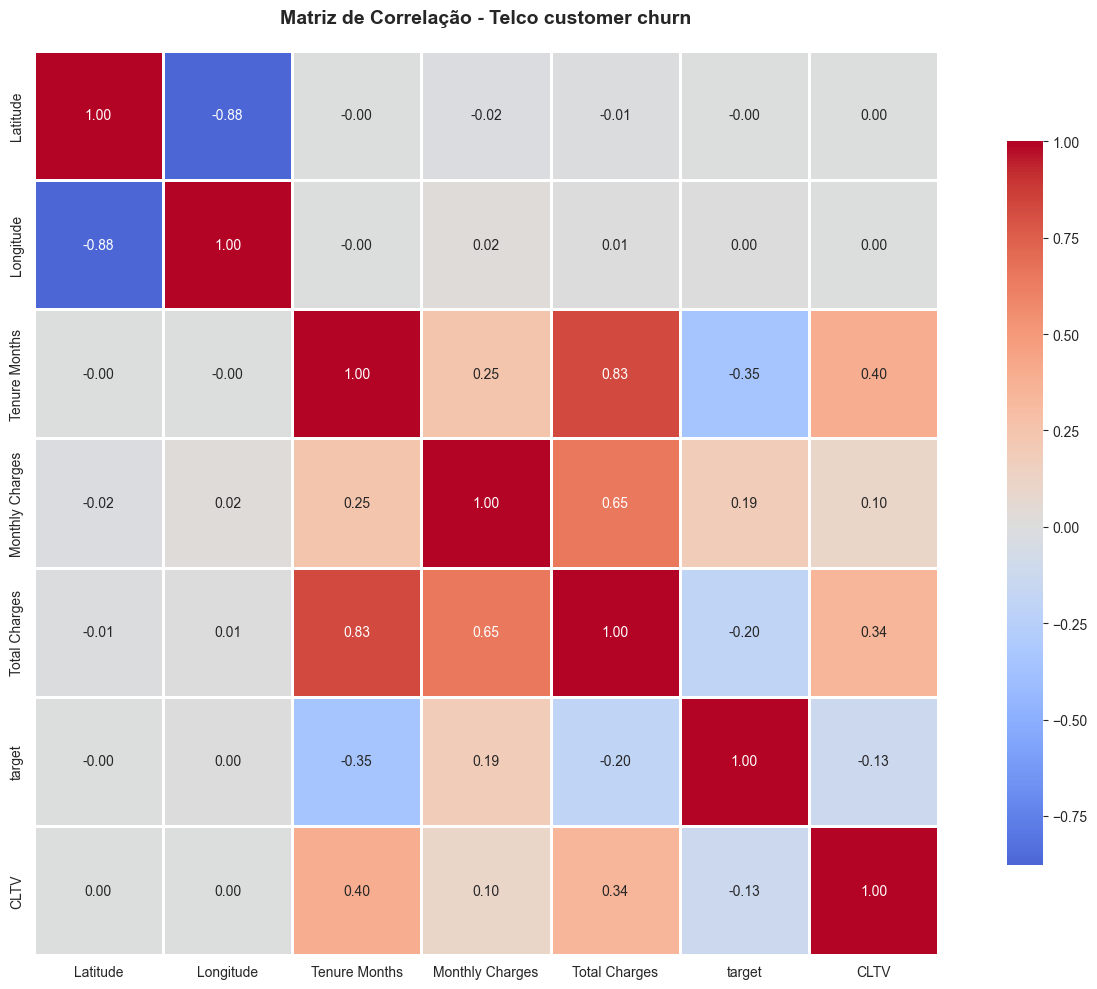

=== CORRELAÇÕES COM A VARIÁVEL TARGET ===

target             1.000000
Monthly Charges    0.193356
Longitude          0.004594
Latitude          -0.003384
CLTV              -0.127463
Total Charges     -0.198324
Tenure Months     -0.352229
Name: target, dtype: float64

=== MULTICOLINEARIDADE (Correlação entre features) ===
Pares de features com correlação > 0.7:

    Feature 1     Feature 2  Correlação
Tenure Months Total Charges       0.826
     Latitude     Longitude      -0.877

⚠️ Alta correlação entre features pode causar multicolinearidade!


In [ ]:
# Matriz de correlação apenas para colunas numéricas
corr_numeric = df.select_dtypes(include=[np.number]).corr()

# Visualizar matriz de correlação
plt.figure(figsize=(14, 10))
sns.heatmap(corr_numeric, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação - Telco customer churn', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Identificar correlações fortes com o target
print("=== CORRELAÇÕES COM A VARIÁVEL TARGET ===\n")
target_corr = corr_numeric['target'].sort_values(ascending=False)
print(target_corr)

# Identificar pares de features com alta correlação (possível multicolinearidade)
print("\n=== MULTICOLINEARIDADE (Correlação entre features) ===")
print("Pares de features com correlação > 0.7:\n")

high_corr_pairs = []
for i in range(len(corr_numeric.columns)):
    for j in range(i+1, len(corr_numeric.columns)):
        if abs(corr_numeric.iloc[i, j]) > 0.7 and corr_numeric.columns[i] != 'target' and corr_numeric.columns[j] != 'target': # type: ignore
            high_corr_pairs.append({
                'Feature 1': corr_numeric.columns[i],
                'Feature 2': corr_numeric.columns[j],
                'Correlação': round(corr_numeric.iloc[i, j], 3) # type: ignore
            })

if len(high_corr_pairs) > 0:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(by='Correlação', ascending=False)
    print(high_corr_df.to_string(index=False))
    print("\n⚠️ Alta correlação entre features pode causar multicolinearidade!")
else:
    print("✓ Nenhuma correlação forte detectada entre features (excluindo target)")

## 4. Preparação dos dados =========================

### 4.1 Tratamento de Missing Values

Encontramos Missing Values em apenas 2 colunas: "Churn Reason" e "Total Charges"
- A coluna "Churn Reason" apresentou 5174 valores ausentes, o que é esperado, pois esse campo só é populado após a saída do cliente da empresa. Como visto na seção de distribuição da variável target, temos a seguinte distribuição no dataset:

|valor|quantidade|
|---|-------|
|0 | 5174|
|1 | 1869|

A coluna "Total Charges" apresentou 11 valores ausentes, que **foram preenchidos com 0**, pois é razoável assumir que clientes sem cobranças registradas não tiveram gastos.

### 4.2 Valores distintos das colunas

Aqui transformamos o dataset em uma tabela com as colunas preenchendo as linhas e as colunas sendo seus respectivos valores únicos. Assim, temos uma noção geral dos valores distintas de cada coluna

In [10]:
cols = df.columns.tolist()

unique_values = {}

for col in cols:
    unique_values[col] = pd.Series(df[col].unique())

df_unique_values = pd.DataFrame(unique_values).T
df_unique_values['count'] = df_unique_values.count(axis=1)
df_unique_values = df_unique_values[['count'] + df_unique_values.columns[:-1].tolist()]
df_unique_values

,count,0,1,2,3,4,5,6,7,8,...,7033,7034,7035,7036,7037,7038,7039,7040,7041,7042
CustomerID,7043,3668-QPYBK,9237-HQITU,9305-CDSKC,7892-POOKP,0280-XJGEX,4190-MFLUW,8779-QRDMV,1066-JKSGK,6467-CHFZW,...,0871-OPBXW,3605-JISKB,9767-FFLEM,8456-QDAVC,7750-EYXWZ,2569-WGERO,6840-RESVB,2234-XADUH,4801-JZAZL,3186-AJIEK
Country,1,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,1,California,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,1129,Los Angeles,Beverly Hills,Huntington Park,Lynwood,Marina Del Rey,Inglewood,Santa Monica,Torrance,Whittier,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,1652,90003,90005,90006,90010,90015,90020,90022,90024,90028,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lat Long,1652,"33.964131, -118.272783","34.059281, -118.30742","34.048013, -118.293953","34.062125, -118.315709","34.039224, -118.266293","34.066367, -118.309868","34.02381, -118.156582","34.066303, -118.435479","34.099869, -118.326843",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,1652,33.964131,34.059281,34.048013,34.062125,34.039224,34.066367,34.02381,34.066303,34.099869,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Longitude,1651,-118.272783,-118.30742,-118.293953,-118.315709,-118.266293,-118.309868,-118.156582,-118.435479,-118.326843,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,2,Male,Female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Senior Citizen,2,No,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Analisando os valores únicos das colunas notamos algumas colunas redundantes e outras com valores irrelevantes para o treinamento. 

Com isso, realizaremos a deleção dos seguintes campos:
- **"Churn Reason"**  - não é um dado utilizado para inferência. É a razão do cliente ter saído
- **"Churn Label"**  - contém a mesma informação do campo "Churn Value"
- **"Count"** - possui o mesmo valor para todos os registros, não tem utilidade para o modelo
- **"Lat Long"**  - é a junção das colunas Latitude e Longitude
- **"Country"** - possui apenas um valor, não tem utilidade para o modelo
- **"State"** - possui apenas um valor, não tem utilidade para o modelo
- **"CustomerID"** - é um identificador único, não tem utilidade para o modelo

In [17]:
df_clean = df.drop(columns=['Churn Reason', 'Churn Label', 'Lat Long', 'Country', 'State', 'CustomerID', 'City', 'Zip Code'])

print("Shape final:", df_clean.shape)
print("\nMissing values restantes:")
print(df_clean.isna().sum().sort_values(ascending=False).head(20))

print("\nTipos de dados:")
print(df_clean.dtypes.value_counts())

Shape final: (7043, 23)

Missing values restantes:
Latitude             0
Longitude            0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
dtype: int64

Tipos de dados:
object     16
float64     4
int64       3
Name: count, dtype: int64


In [18]:
df_clean.to_csv("../data/processed/telco_customer_churn_eda_pre-processed.csv", index=False)

### 4.3 Feature Engineering — Total Charges

Nesta etapa, criamos transformações para enriquecer a variável `Total Charges`, reduzindo assimetria, padronizando comportamento acumulado e gerando uma feature derivada mais interpretável para o modelo.

In [19]:
# Garantir tipo numérico
df_clean['Total Charges'] = pd.to_numeric(df_clean['Total Charges'], errors='coerce')

# Se ainda existir missing em clientes com tenure 0, preencher com 0
df_clean.loc[
    (df_clean['Tenure Months'] == 0) & (df_clean['Total Charges'].isna()),
    'Total Charges'
] = 0

# Conferir se restaram missing
print("Missing em Total Charges:", df_clean['Total Charges'].isna().sum())

# Feature derivada: gasto médio mensal aproximado
df_clean['avg_ticket'] = df_clean['Total Charges'] / (df_clean['Tenure Months'] + 1)

# Log transform para reduzir assimetria
df_clean['Total Charges Log'] = np.log1p(df_clean['Total Charges'])

# Opcional: log da feature derivada
df_clean['avg_ticket_log'] = np.log1p(df_clean['avg_ticket'])

# Conferência rápida
df_clean[['Total Charges', 'Total Charges Log', 'avg_ticket', 'avg_ticket_log']].head()

Missing em Total Charges: 0


,Total Charges,Total Charges Log,avg_ticket,avg_ticket_log
0,108.15,4.692723,36.050000,3.612268
1,151.65,5.028148,50.550000,3.942552
2,820.50,6.711132,91.166667,4.523599
3,3046.05,8.021929,105.036207,4.663781
4,5036.30,8.524626,100.726000,4.622283
